BÀI 1

In [2]:
import numpy as np

text = [
    "I love machine learning",
    "Machine learning is fun",
    "I enjoy deep learning",
    "Deep learning needs data",
    "MLIoT Lab is fantastic",
    "My computer is dying",
    "They are so energetic",
    "Done"
]

vocab = sorted({w for s in text for w in s.lower().split()})
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v
X = np.array([to_vector(s) for s in text])
print(X.shape)

(8, 21)


- Mỗi hàng đại diện cho 1 câu ( 8 câu -> 8 hàng)
- Mỗi cột đại diện cho 1 từ trong vocab (21 từ -> 21 cột)
- X[i,j] là số lần từ thứ j xuất hiện trong câu thứ i

In [3]:
print("X.shape = ", X.shape)
mean_vec = X.mean(axis = 0)
print("mean_vec.shape = ", mean_vec.shape)
Xc = X - mean_vec
print("Xc.shape = ", Xc.shape)

X.shape =  (8, 21)
mean_vec.shape =  (21,)
Xc.shape =  (8, 21)


In [4]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

S = cosine_similarity(X)
print(np.round(S, 2))

[[1.   0.5  0.5  0.25 0.   0.   0.   0.  ]
 [0.5  1.   0.25 0.25 0.25 0.25 0.   0.  ]
 [0.5  0.25 1.   0.5  0.   0.   0.   0.  ]
 [0.25 0.25 0.5  1.   0.   0.   0.   0.  ]
 [0.   0.25 0.   0.   1.   0.25 0.   0.  ]
 [0.   0.25 0.   0.   0.25 1.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   1.  ]]


In [5]:
def search(query, top_k = 3):
    q = to_vector(query).reshape(1, -1)
    sims = cosine_similarity(q, X).ravel() 
    idx = np.argsort(sims)[::-1][:top_k]
    return [(int(i), float(sims[i])) for i in idx]

query = "deep learning data"
print(f"Query: {query!r}")
for i, score in search(query, top_k=3):
    print(f"  c{i}  {score:.3f}  ")

Query: 'deep learning data'
  c3  0.866  
  c2  0.577  
  c0  0.289  


*** Nhận xét ***
- Dựa vào ma trận tương đồng, ta thấy các cặp câu: câu 1 và 2; 1 và 3; 3 và 4 đều có hệ số tương đồng cao nhất (0.5)
- Trực quan:
    + Câu 1: "I love machine learning"
    + Câu 2: "Machine learning is fun"
    + Câu 3: "I enjoy deep learning"
    + Câu 4: "Deep learning needs data"
- Câu 1 và 2 chung "machine learning"
- Câu 1 và 3 chung "I" + "learning" 
- Câu 3 và 4 chung "deep learning"
- Các cặp câu có hệ số tương đồng bằng 0 là không từ vựng nào tương đồng, nhưng câu khác biệt nhất là câu 7 "They are so energetic" và câu 8 "Done" vì cả hàng và cột của ma trận đều bằng 0 tức là không có điểm chung với tất cả các câu còn lại 


BÀI 2

In [6]:
Xc = X - X.mean(axis=0)      
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:, :2] * S[:2]      

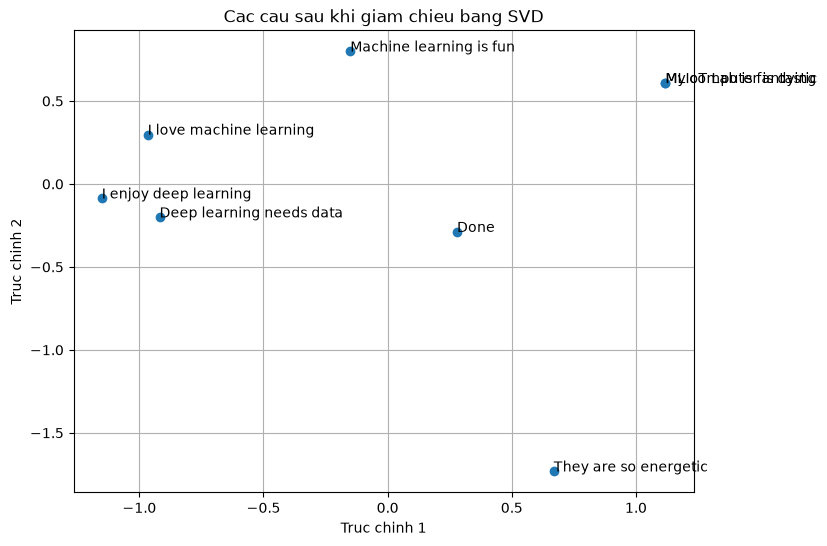

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1])
for i, s in enumerate(text):
    plt.annotate(s, (coords[i, 0], coords[i, 1]))
plt.xlabel("Truc chinh 1")
plt.ylabel("Truc chinh 2")
plt.title("Cac cau sau khi giam chieu bang SVD")
plt.grid(True)
plt.show()

*** Nhận xét ***
- Các câu cùng chủ đề là câu 1,2,3,4 (machine learning) đều nằm gần nhau
- Vì ta đã trừ trung bình (Xc = X - X.mean(axis=0)) trước khi phân rã, SVD trên dữ liệu đã center tương đương với PCA. Các hàng của Vt chính là các trục chính (principal axes) — tức eigenvector của ma trận hiệp phương sai — và bình phương giá trị kỳ dị S² tỉ lệ với phương sai dọc mỗi trục. Trục chính 1 là hướng dữ liệu biến thiên mạnh nhất; ở đây nó tự động nắm bắt khác biệt chủ đề lớn nhất (học máy vs phần còn lại), nên giữ lại 2 trục mạnh
nhất đã đủ để tách các cụm.